# P-A

### Load predictions

In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path 
import plotly.express as px
from scipy.optimize import minimize_scalar
from scipy.stats import linregress
from sklearn.metrics import PrecisionRecallDisplay

p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv')

df = pd.read_csv(p, index_col='survey_id', dtype = {22:str, 24:str, 25:str})

first_species_index = list(df.columns).index('eventDate') + 1
species_columns = df.columns[first_species_index:-1]
targets = df.loc[df['subset'] == 'test', species_columns]

# Test dataset summary
targets_tb = targets.sum(axis=1)
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)

In [2]:
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '15_humenv_cat_pa-2025-03-11_10-32-preds' / 'predictions-probs.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')
#predictions = np.exp(predictions) - 1

predictions_tb = predictions.sum(axis=1)
predictions_sr = (predictions > 0).sum(axis=1)
predictions_prev = (predictions > 0).sum(axis=0)

### Extract best species

In [5]:
# PrecisionRecallDisplay.from_predictions(targets_pres.to_numpy().flatten(), predictions.to_numpy().flatten())

In [ ]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(targets_pres.to_numpy(), predictions.to_numpy(), average=None)

In [ ]:
aps = pd.DataFrame({"AP":ap, "prev":(targets[species_columns] > 0).sum(axis=0)}, index=species_columns)
aps.sort_values(ascending=False, by ='AP', inplace = True)
aps.iloc[0:10]

In [19]:
best_species = aps.iloc[0:10]

#best_species.to_csv(pred_path.parent / 'best_species_300.csv')
best_pred_path = output_path / '15_humenv_cat_pa-2025-03-11_10-32-preds' / 'predictions-probs-best10.csv'

df1 = predictions[list(best_species.index)]
df2 = df[['latitude', 'longitude', 'depth', 'eventDate']]
pd.concat([df2, df1], axis=1, join="inner").to_csv(best_pred_path)


Produce best species file for training

In [3]:
bestpredspath = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/best10')

def save_line(row):
    np.save(bestpredspath / f"{row.name}.npy", row.values.astype(float))

In [4]:
from tqdm.auto import tqdm
tqdm.pandas()

best_pred_path = output_path / '15_humenv_cat_pa-2025-03-11_10-32-preds' / 'predictions-probs-best10.csv'
best_pred = pd.read_csv(best_pred_path, index_col='survey_id')
best_species = best_pred.columns[4:]
groundtruth = df.loc[df['subset'] != 'test' , best_species] > 0
to_save = pd.concat([groundtruth, best_pred[best_species]])
to_save.progress_apply(save_line, axis=1)

  0%|          | 0/27437 [00:00<?, ?it/s]

survey_id
923400045    None
923400036    None
923400037    None
923400043    None
923402703    None
             ... 
712300818    None
712301159    None
712301158    None
712301157    None
712301156    None
Length: 27437, dtype: object

In [21]:
save_line(to_save.iloc[0])

In [7]:
to_save.iloc[0].values.astype(float)

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

### Plotting Best species

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

i = 0
for s in list(best_species.index):
    # print(f"{s}: AP: {best_species.loc[s,'AP']}, prevalence = {targets_prev[s]}")
    # PrecisionRecallDisplay.from_predictions(targets_pres[s].to_numpy(), predictions[s].to_numpy())
    # plt.savefig(f"/home/gaetan/Desktop/predictions/14_humenv_pa-2025-03-04_11-45-preds/PR-curves/{s}.png")

    numbins = 2

    cm = confusion_matrix((targets[s]>0).to_numpy().astype(int), (predictions[s]>0.5).to_numpy().astype(int), labels=range(numbins), normalize = 'true')
    cm = cm.round(3)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"absent (N={len(targets) - targets_prev[s]})", f"present (N={targets_prev[s]})"])
    disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax, cmap = 'Blues')
    disp.ax_.set_title(f"{s} - AP: {best_species.loc[s,'AP']:.2f},\n prevalence = {targets_prev[s]}")
    plt.tight_layout()
    plt.savefig(pred_path.parent / 'cm' / f'{i}_{s}.png')
    #plt.show()
    i += 1

In [4]:
import plotly.express as px
best_species = pd.read_csv(pred_path.parent / 'best_species_300.csv', index_col = 0)
best_species['genus'] = best_species.index.to_series().apply(lambda x: str(x).split()[0])

px.scatter(best_species, x='prev', y='AP', color='genus')


### Interpretation

In [20]:
best_species = pd.read_csv(pred_path.parent / 'best_species.csv', index_col = 0)
species = list(best_species.index)

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '15_humenv_cat_pa-2025-03-11_10-32-preds' /' predictions-probs.csv'

ig_name = '15_humenv_cat_pa-2025-05-07_14-54'
ig_path = output_path / ig_name / 'integrated_gradients'

In [21]:
labels = ["fsle", "fsle-orientation", "bathymetry_aus", "chlorophyll", "sst", "salinity3d", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "prot_level", "distance-to-port", "pop-density-log", "gravity"]

In [ ]:
from scipy.stats import gaussian_kde
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly
colors = plotly.colors.qualitative.Light24

def produce_charts(speci):

    presences = []
    absences = []
    for survey_id in list(targets.index):

        ig = np.load(ig_path / speci / f"ig_{survey_id}.npy")

        abs_ig = np.abs(ig).squeeze()
        averages = abs_ig.mean(axis=(1,2))

        if df.loc[survey_id, s] > 0:
            presences.append(averages)
        else:
            absences.append(averages)

    
    presences = np.vstack(presences)
    absences = np.vstack(absences)

    p = pd.DataFrame(presences)
    a = pd.DataFrame(absences)
    a.columns = labels
    p.columns = labels

    fig = make_subplots(rows=2, cols=1, subplot_titles=("Presence", "Absence"))

    # Plot density for each column
    for i in range(len(a.columns)):
        column = a[s].columns[i]

        density = gaussian_kde(p[column])
        xs = np.linspace(p[column].min(), p[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=1, col=1)

        density = gaussian_kde(a[column])
        xs = np.linspace(a[column].min(), a[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=2, col=1)

    # Update layout
    fig.update_layout(title=speci,
                    xaxis_title='Value',
                    yaxis_title='Density',
                    template='plotly_white',
                    height = 800)

    # Show plot
    fig.update_yaxes(range=[0, 600]) 
    fig.update_xaxes(range=[0, 0.03]) 
    fig.write_image(output_path / ig_name / "ig_densities" / f"{s}.png")

In [ ]:
import multiprocessing
from multiprocessing import Pool

with multiprocessing.Pool(processes=18) as pool:
        results = pool.map(produce_charts, species)

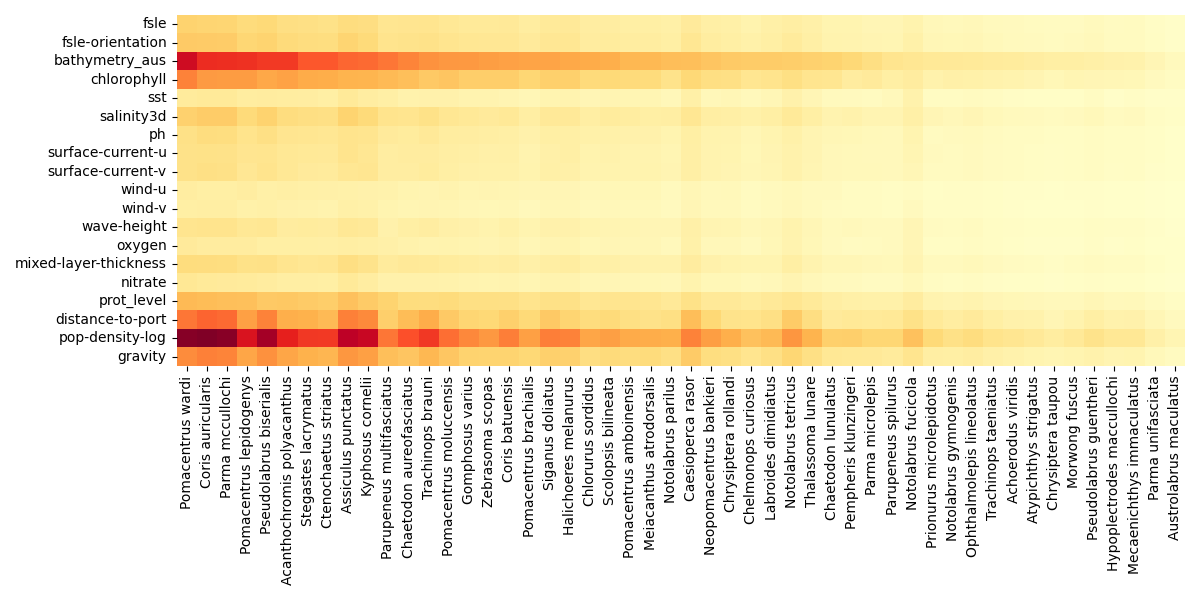

In [23]:
import matplotlib.pyplot as plt
%matplotlib widget

import seaborn as sns

# Create chart

series_dict = {}

for i in range(len(species)):
    s = species[i]
    p = Path(output_path / ig_name / "ig_stats" / f"{s}_pres.csv")
    if p.exists():
        df = pd.read_csv(p, index_col = 0)
        series_dict[s] = df['50%']

df = pd.concat(series_dict, axis = 1).T
df.sort_values(ascending=False, by = 'bathymetry_aus', inplace = True)
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(df.T, ax = ax, cbar=False, cmap='YlOrRd')
plt.tight_layout()


#### Species richness

In [ ]:
from scipy.stats import linregress

print(linregress(targets['sr'], predictions['sr']))


LinregressResult(slope=0.6993442347674865, intercept=6.648082016804121, rvalue=0.7330181721457234, pvalue=0.0, stderr=0.009222999899645324, intercept_stderr=0.2699004201674971)


In [ ]:
fig = px.scatter(
    x=np.log(1+targets_sr), y=np.log(1+predictions_sr),
    marginal_y='violin', marginal_x='violin'
)
fig.update_layout(width=800, height=800)
fig.show()


## Abundance

### Species R2

In [9]:
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

r2s = {}

for s in species_columns:
    groundtruth = targets[s]
    preds = predictions[s]

    #r2s[s] = r2_score(np.log(1+groundtruth), np.log(1+preds))
    r2s[s] = r2_score(groundtruth, preds)
    #r2s[s] = spearmanr(groundtruth, preds)


r2s = pd.Series(r2s)

In [14]:
np.log(1+targets).to_numpy().flatten().mean()

0.06144996238274414

In [10]:
sp_occ= np.log(1+(targets[species_columns] > 0).sum(axis=0))

In [11]:
df = pd.concat([sp_occ, r2s], axis = 1)
df.columns = ['occurrences', 'r2']
df['species'] = df.index
df


,occurrences,r2,species
Abalistes stellatus,1.386294,-0.000587,Abalistes stellatus
Abudefduf bengalensis,5.337538,-0.010204,Abudefduf bengalensis
Abudefduf septemfasciatus,0.693147,-0.000202,Abudefduf septemfasciatus
Abudefduf sexfasciatus,5.509388,0.015168,Abudefduf sexfasciatus
Abudefduf sordidus,0.000000,1.000000,Abudefduf sordidus
...,...,...,...
Zebrasoma scopas,5.673323,0.080799,Zebrasoma scopas
Zebrasoma velifer,5.313206,0.041676,Zebrasoma velifer
Zoramia leptacanthus,1.386294,-0.000372,Zoramia leptacanthus
Zoramia spp.,0.693147,-0.000202,Zoramia spp.


In [12]:
df[df['occurrences'] >= 5]['r2'].describe()

count    188.000000
mean      -0.093577
std        0.369866
min       -2.997035
25%       -0.047901
50%       -0.010634
75%        0.026875
max        0.286399
Name: r2, dtype: float64

In [ ]:


spearmanr()

In [16]:
import plotly.express as px

common = df[df['occurrences'] >= 3]
fig = px.scatter(common, x="occurrences", y="r2", hover_data = "species")
fig.show()

### Species richness

In [ ]:
# # Find best threshold for species richness

# def rvalue(thres, df, target_sr):
#     df['clean_sr'] = np.log(1+df[df > thres].sum(axis=1))
#     _, _, rval, _, _ = linregress(target_sr, df['clean_sr'])
#     return(-rval)


# threshold = minimize_scalar(rvalue, args=(predictions, targets['sr']),method='Bounded', bounds=(0,1))['x']
# print(threshold)

In [ ]:
clean_preds = predictions.copy()
#clean_preds[clean_preds < threshold] = 0

clean_preds['tb'] = np.log(1+clean_preds.sum(axis=1))
clean_preds['sr'] = np.log(1+(clean_preds > 0).sum(axis=1))

<Axes: xlabel='None', ylabel='None'>

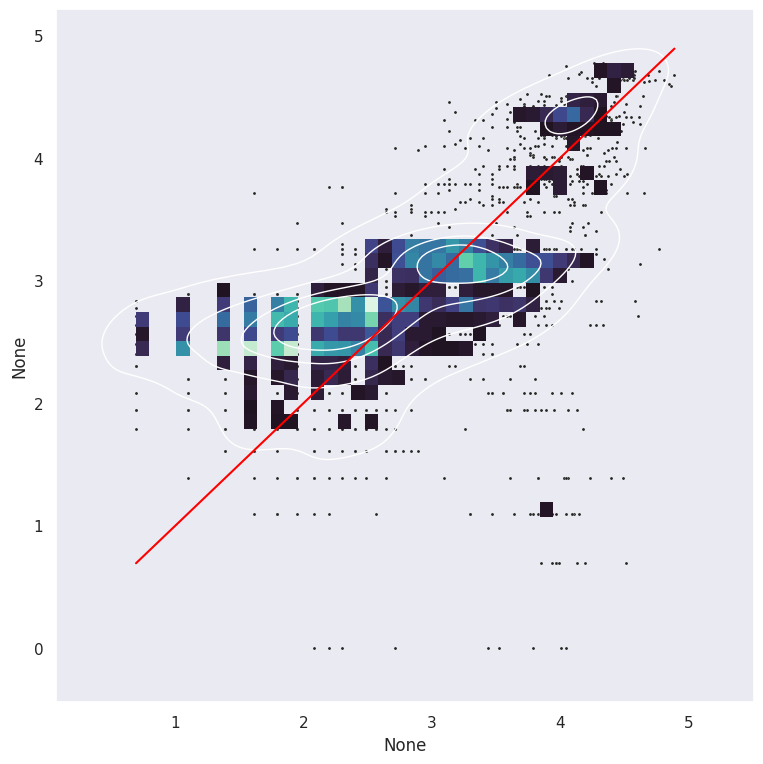

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

# df = df[df['r2'] > -1]
# x, y = df["occurrences"], df["r2"]

#x, y = np.log(1+targets_prev), np.log(1+predictions_prev)
x, y = np.log(1+targets_sr), np.log(1+predictions_sr)
#x, y = np.log(1+targets_tb), np.log(1+predictions_tb)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')

## Explore predictions (classif)

In [13]:
import numpy as np
import pandas as pd 
from pathlib import Path 
import plotly.express as px
from scipy.optimize import minimize_scalar
from scipy.stats import linregress

#p = Path('/mnt/marbec-data/RLS-Australia/malpolon/inputs/cyril/database_cyril_final_split.csv')
#df = pd.read_csv(p, index_col='survey_id')

p = Path('/mnt/marbec-data/RLS-Australia/malpolon/inputs/database_split_binned-25.csv')
df = pd.read_csv(p, index_col='survey_id', dtype = {22:str, 24:str, 25:str})

first_species_index = list(df.columns).index('eventDate') + 1
species_columns = df.columns[first_species_index:-1]
targets = df.loc[df['subset'] == 'test', species_columns]
targets = (targets != 0).astype(int)
target_sr = targets.sum(axis=1)

In [14]:
pred_path = Path('/mnt/marbec-data/RLS-Australia/malpolon/outputs/9_env_pa-2025-02-07_11-48-preds/predictions-probs.csv')
predictions = pd.read_csv(pred_path, index_col='survey_id')

preds = predictions[species_columns]

In [15]:
# Find best threshold for species richness

def rvalue(thres, df, target_sr):
    sr = (df > thres).astype(int).sum(axis=1)
    return np.abs(sr.mean() - target_sr.mean())


threshold = minimize_scalar(rvalue, args=(preds, target_sr),method='Bounded', bounds=(0,1))['x']
print(threshold)

0.9609450612987809


In [16]:
presences = (preds > threshold).astype(int)

In [ ]:
presences.to_csv(pred_path.parent / 'presences.csv')

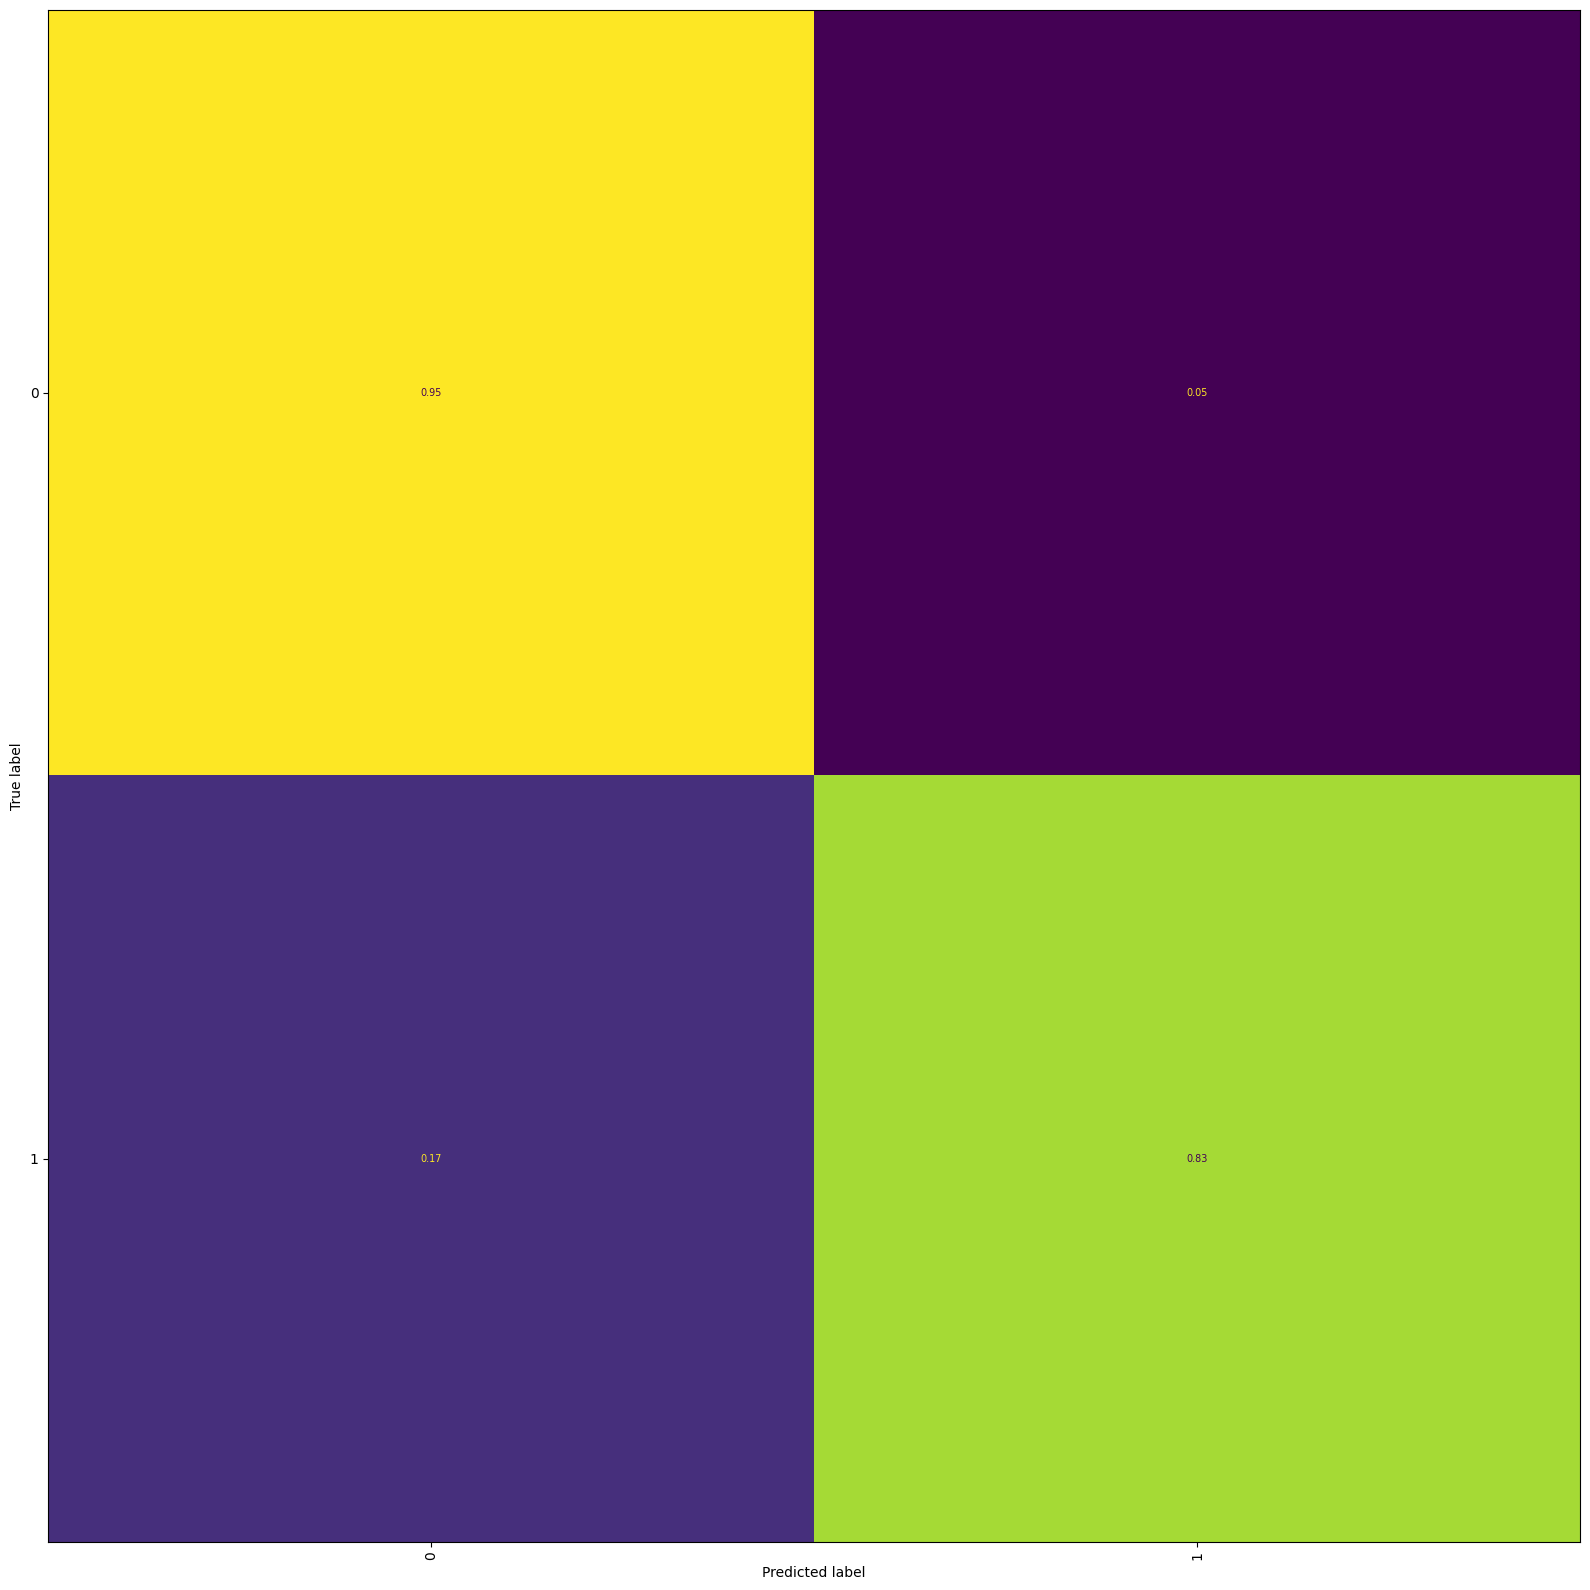

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from matplotlib import pyplot as plt

numbins = targets.to_numpy().max() + 1

cm = confusion_matrix(targets.to_numpy().flatten(), (predictions>0.5).to_numpy().flatten(), labels=range(numbins), normalize = 'true')
cm = cm.round(2)

fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(numbins))
disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax)
plt.tight_layout()
plt.show()
#plt.savefig(pred_path.parent / 'confusion_matrix.png')



In [20]:
# F1 by site

f1scores = []
test_df = df[df['subset'] == 'test']

for site in test_df['site_code'].unique():
    surveys = test_df[test_df['site_code'] == site].index
    lat, lon = test_df.loc[surveys[0], 'latitude'], test_df.loc[surveys[0], 'longitude']
    preds = (predictions > 0.5).astype(float).loc[surveys, species_columns].to_numpy().flatten()
    targets = (test_df != 0).astype(float).loc[surveys, species_columns].to_numpy().flatten()
    f1 = f1_score(targets, preds)
    f1scores.append({'site':site, 'f1':f1, 'lat':lat, 'lon':lon})

pd.DataFrame(f1scores).to_csv(pred_path.parent / 'f1_by_site.csv')


In [1]:
from matplotlib import pyplot as plt
class_indices = np.arange(25)
distances = np.abs(np.log(1+np.expand_dims(class_indices,0)) - np.log(1+np.expand_dims(class_indices,1)))


log_indices = np.log(1+np.arange(25))
distances = np.abs(np.expand_dims(log_indices,0) - np.expand_dims(log_indices,1))
#distances = np.abs(np.expand_dims(np.arange(25),0) - np.expand_dims(np.arange(25),1))
#distances = np.square(distances)
distances = 0.5+0.5*distances / distances.max() - 0.5* np.eye(25)
plt.matshow(distances)

NameError: name 'np' is not defined

In [25]:
distances.max()

1.0

## Compare performances

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, balanced_accuracy_score
from matplotlib import pyplot as plt

In [2]:
p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv')
df = pd.read_csv(p, index_col='survey_id', dtype = {22:str, 24:str, 25:str})

first_species_index = list(df.columns).index('eventDate') + 1
species_columns = df.columns[first_species_index:-1]
targets = df.loc[df['subset'] == 'test', species_columns]
targets = (targets != 0).astype(int)

In [ ]:
checkpoints = {'9_env_pa-2025-02-04_16-46-preds' : 'Environment17',
               '10_sat_pa-2025-02-05_17-32-preds' : 'Satellite',
               '11_satenv_pa-2025-02-06_11-50-preds' : 'Environment + Satellite',
               '9_env_pa-2025-03-11_10-31-preds' : 'Environment15',
               '13_hum_pa-2025-03-11_10-29-preds' : 'Human activities',
               '15_humenv_cat_pa-2025-03-11_10-32-preds' : 'Environment + Human activities<br><b>monomodal</b>',
               '14_humenv_pa-2025-03-04_11-45-preds' : 'Environment + Human activities<br><b>multimodal</b>',
               '18_humenv_dhw_cat_pa-2025-05-16_12-02-preds' : 'Envhum+DHW',
               '20_humenv_best10_pa-2025-05-15_15-21' : 'Envhum+Best10',
               '22_humenv_dhw_best10_pa-2025-05-16_13-47-preds': 'Envhum+DHW+Best10',

               }


points = []

for cp in checkpoints:
    try:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions-probs.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    except Exception as e:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    predictions = (predictions >= 0.5).astype(int)
    f1 = f1_score(targets, predictions, average='weighted')
    macacc = balanced_accuracy_score(targets.to_numpy().flatten(), predictions.to_numpy().flatten())
    FP = ((targets == 0) & (predictions == 1)).to_numpy().sum() / (targets == 0).to_numpy().sum()
    FN = ((targets == 1) & (predictions == 0)).to_numpy().sum() / (targets == 1).to_numpy().sum()
    points.append({'f1': f1, 'macro_acc':macacc, 'label': checkpoints[cp], 'False Positives':FP, 'False Negatives':FN})
    

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [4]:
import plotly.express as px
data = pd.DataFrame(points)
data['size'] = 12

fig = px.scatter(data,
                 x='False Positives',
                 y='False Negatives',
                 color='label',
                 text='label',
                 size = 'size',
                 template='simple_white',
                 width=800,
                 height=1000)

fig.update_layout(showlegend=False)
fig.update_yaxes(   scaleanchor="x",
                    scaleratio=1)
fig.update_traces(textposition='middle right',  textfont=dict(size=20))

fig.show()